In [2]:
# Import given data set
import numpy as np
import pandas as pd

marketing_data = pd.read_csv("marketing_data.csv")
marketing_data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,05-11-2014,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,04-08-2014,0,6,...,2,7,1,0,0,0,0,1,0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,"$66,476.00",0,1,03-07-2013,99,372,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,Married,"$31,056.00",1,0,1/22/13,99,5,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,Divorced,"$46,310.00",1,0,12-03-2012,99,185,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,Married,"$65,819.00",0,0,11/29/12,99,267,...,10,3,0,0,0,0,0,0,0,IND


In [3]:
#Process to be follow .
# ================================================================================================================
# 1. Identify the type of data for each column (Numerical , Categorical, Ordinal and PureString)
# 2. Check and remove all Duplicate Records from the dataframe
# 3. Check and remove all Duplicate Columns from the dataframe
# 4. If your column is Numerical column, perform the following:
#
#               - If dealing with Continuous ND, check w.r.t domain whether the following parameter is valid or not
#                       a. Positive Numbers are allowed or not
#                       b. Negative Numbers are allowed or not
#                       c. Decimals are allowed or not
#
#                 If any of the above is not allowed, DELETE THAT COLUMN ENTRY
#
#               - If dealing with Discrete ND, check w.r.t domain whether the following parameter is valid or not
#                       a. Positive Numbers are allowed or not
#                       b. Negative Numbers are allowed or not
#                       c. Decimals are allowed or not
#                       d. Check whether the numbers fall in a specified range as defined by the domain.
#
#                 If any of the above is not allowed, DELETE THAT COLUMN ENTRY
#
# 5. If the columns are Categorical columns, perform the following
#
#       a. Get the unique values of the column
#       b. Handle the data that has SPELLING ERRORS, CASE ERRORS (Normalization), or any FORMATTING ERRORS. Ensure CASE is UNIFIED
#       c. Check whether the categories/groups found in the unique values match the domain spec.
#
#    If any unusual category found, DELETE THAT SPECIFIC RECORD.
#
#
# 6. If the columns are Ordinal columns, perform the following
#
#       a. Get the unique values of the column
#       b. Handle the data that has SPELLING ERRORS, CASE ERRORS (Normalization), or any FORMATTING ERRORS. Ensure CASE is UNIFIED
#       c. Check whether the categories/groups found in the unique values match the domain spec.
#.      d. Check the rank of each unique category is mentioned/specified by the domain
#
#    If any unusual category/rank found, DELETE THAT SPECIFIC RECORD.
#
# 7. If dealing with DATE column, convert the datatype of the column into datetime and extract the relevant data from date column.
#
# 8. If dealing with PURE STRING COLUMN, ------------ DONT TOUCH THAT COLUMN till you learn NLP ;)

In [4]:
#1. Get data info for each column
marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

 1. Identify the type of data for each column (Numerical , Categorical, Ordinal
 and PureString)

In [5]:
# Identify the type of data for each column (Numerical , Categorical, Ordinal and PureString)

#   Column                                               Non-Null Count  Dtype
# ==================================================================================================================
# 0   ID   (Customer's unique identifier)                2240 non-null   int64   ----------- ND(Discrete)
# 1   Year_Birth (Customer's birth year )                2240 non-null   int64   ----------- ND(Discrete)
# 2   Education (Customer's education level)             2240 non-null   object  ----------- Categorical
# 3   Marital_Status (Customer's marital status)         2240 non-null   object  ----------- Categorical
# 4   Income (Customer's yearly household income)        2216 non-null   object  ----------- ND(Continous)
# 5   Kidhome (number of small children in house)        2240 non-null   int64   ----------- ND(Discrete)
# 6   Teenhome (no of teenagers in customer's house)     2240 non-null   int64  ------------ ND(Discrete)
# 7   Dt_Customer (Date of customer's enrollment)        2240 non-null   object ------------ ND(Discrete)
# 8   Recency (number of days since the last purchase)   2240 non-null   int64  ------------ ND(Discrete)
# 9   MntWines (amount spent on wine in last 2 years)    2240 non-null   int64  ------------ ND(Continous)
# 10  MntFruits (amount spent on fruits in last 2 years) 2240 non-null   int64  ------------ ND(Continous)
# 11  MntMeatProducts (spent on meat in last 2 years)    2240 non-null   int64  ------------ ND(Continous)
# 12  MntFishProducts (spent on fishin last 2 years)     2240 non-null   int64  ------------ ND(Continous)
# 13  MntSweetProducts (spent on sweet-last 2 years)     2240 non-null   int64  ------------ ND(Continous)
# 14  MntGoldProds (spent on gold in last 2 years)       2240 non-null   int64  ------------ ND(Continous)
# 15  NumDealsPurchases(purchases made with discount)    2240 non-null   int64  ------------ ND(Discrete)
# 16  NumWebPurchases(purchases on company's website)    2240 non-null   int64  ------------ ND(Discrete)
# 17  NumCatalogPurchases(purchases via catelogue)       2240 non-null   int64  ------------ ND(Discrete)
# 18  NumStorePurchases(purchases directly in store)     2240 non-null   int64  ------------ ND(Discrete)
# 19  NumWebVisitsMonth (visits to company's website)    2240 non-null   int64  ------------ ND(Discrete)
# 20  AcceptedCmp3(customer accepted offer in 3rd cmp)   2240 non-null   int64  ------------ ND(Discrete)
# 21  AcceptedCmp4(customer accepted offer in 4th cmp)   2240 non-null   int64  ------------ ND(Discrete)
# 22  AcceptedCmp5(customer accepted offer in 5th cmp)   2240 non-null   int64  ------------ ND(Discrete)
# 23  AcceptedCmp1(customer accepted offer in 1st cmp)   2240 non-null   int64  ------------ ND(Discrete)
# 24  AcceptedCmp2(customer accepted offer in 2nd cmp)   2240 non-null   int64  ------------ ND(Discrete)
# 25  Response(customer accepted offer in last cmp)      2240 non-null   int64   ------------ ND(Discrete)
# 26  Complain(customer complained in the last 2 years)  2240 non-null   int64   ------------ ND(Discrete)
# 27  Country (Customer's location)                      2240 non-null   object -------------- Categorical
# dtypes: int64(23), object(5)
# memory usage: 490.1+ KB

 2. Check and remove all Duplicate Records from the dataframe

In [6]:
# Check and remove all Duplicate Records from the dataframe
#
# in Pandas we can detect and remove duplicate records using drop_duplicates()
# ignore_index ---- Used for resetting index if data record removed.
# inplace = True ------- commit the operation in the main df

marketing_data.drop_duplicates(ignore_index=True, inplace=True)

marketing_data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,05-11-2014,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,04-08-2014,0,6,...,2,7,1,0,0,0,0,1,0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,"$66,476.00",0,1,03-07-2013,99,372,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,Married,"$31,056.00",1,0,1/22/13,99,5,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,Divorced,"$46,310.00",1,0,12-03-2012,99,185,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,Married,"$65,819.00",0,0,11/29/12,99,267,...,10,3,0,0,0,0,0,0,0,IND


In [7]:
marketing_data.info()

# Found no duplicates as per info() check in Pre and post drop operation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

3. Check and remove all Duplicate Columns from the dataframe

In [8]:
# As of data check manually and match with definations given in Data Dictionary , No Duplicate columns are found

4. If your column is Numerical column, perform the following:


In [9]:
#  Dealing with CONTINOUS Numerical data :
# ====================================================
#
#               - If dealing with Continuous ND, check w.r.t domain whether the following parameter is valid or not
#                       a. Positive Numbers are allowed or not
#                       b. Negative Numbers are allowed or not
#                       c. Decimals are allowed or not
#
#                 If any of the above is not allowed, DELETE THAT COLUMN ENTRY
#
#
# 4   Income (Customer's yearly household income)        2216 non-null   object  ----------- ND(Continous) ---> +ve allowed,-ve not allowed, no decimals
# 9   MntWines (amount spent on wine in last 2 years)    2240 non-null   int64  ------------ ND(Continous) ---> +ve allowed,-ve not allowed, no decimals
# 10  MntFruits (amount spent on fruits in last 2 years) 2240 non-null   int64  ------------ ND(Continous) ---> +ve allowed,-ve not allowed, no decimals
# 11  MntMeatProducts (spent on meat in last 2 years)    2240 non-null   int64  ------------ ND(Continous) ---> +ve allowed,-ve not allowed, no decimals
# 12  MntFishProducts (spent on fishin last 2 years)     2240 non-null   int64  ------------ ND(Continous) ---> +ve allowed,-ve not allowed, no decimals
# 13  MntSweetProducts (spent on sweet-last 2 years)     2240 non-null   int64  ------------ ND(Continous) ---> +ve allowed,-ve not allowed, no decimals
# 14  MntGoldProds (spent on gold in last 2 years)       2240 non-null   int64  ------------ ND(Continous) ---> +ve allowed,-ve not allowed, no decimals



In [10]:
# Convert Income column to ND

marketing_data['Income'] = marketing_data['Income'].str.replace('$', '')

In [11]:
marketing_data['Income'] = marketing_data['Income'].str.replace(',', '')

In [12]:
# convert Income column to float

marketing_data['Income'] = marketing_data['Income'].astype(float)

In [13]:
marketing_data['Income'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2240 entries, 0 to 2239
Series name: Income
Non-Null Count  Dtype  
--------------  -----  
2216 non-null   float64
dtypes: float64(1)
memory usage: 17.6 KB


In [14]:
# checking if any -ve value in Income column
marketing_data[marketing_data['Income'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [15]:

marketing_data[marketing_data['MntWines'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [16]:
marketing_data[marketing_data['MntFruits'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [17]:
marketing_data[marketing_data['MntMeatProducts'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [18]:
marketing_data[marketing_data['MntFishProducts'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [19]:
marketing_data[marketing_data['MntSweetProducts'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [20]:
marketing_data[marketing_data['MntGoldProds'] < 0]

# None of the CONTINOUS ND column have -Ve Value

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [21]:
#  Deal with DISCRETE ND :
# ===================================
#    If dealing with Discrete ND, check w.r.t domain whether the following parameter is valid or not
#                       a. Positive Numbers are allowed or not
#                       b. Negative Numbers are allowed or not
#                       c. Decimals are allowed or not
#                       d. Check whether the numbers fall in a specified range as defined by the domain.
#
#                 If any of the above is not allowed, DELETE THAT COLUMN ENTRY
#
#
# 0   ID   (Customer's unique identifier)                2240 non-null   int64   ----------- ND(Discrete) - -ve not allow , +ve allow
# 1   Year_Birth (Customer's birth year )                2240 non-null   int64   ----------- ND(Discrete) - -ve not allow , +ve allow
# 5   Kidhome (number of small children in house)        2240 non-null   int64   ----------- ND(Discrete) - -ve not allow , +ve allow
# 6   Teenhome (no of teenagers in customer's house)     2240 non-null   int64  ------------ ND(Discrete) - -ve not allow , +ve allow
# 7   Dt_Customer (Date of customer's enrollment)        2240 non-null   object ------------ ND(Discrete) - -ve not allow , +ve allow (Dates allow only)
# 8   Recency (number of days since the last purchase)   2240 non-null   int64  ------------ ND(Discrete) - -ve not allow , +ve allow
# 15  NumDealsPurchases(purchases made with discount)    2240 non-null   int64  ------------ ND(Discrete) - -ve not allow , +ve allow
# 16  NumWebPurchases(purchases on company's website)    2240 non-null   int64  ------------ ND(Discrete) - -ve not allow , +ve allow
# 17  NumCatalogPurchases(purchases via catelogue)       2240 non-null   int64  ------------ ND(Discrete) - -ve not allow , +ve allow
# 18  NumStorePurchases(purchases directly in store)     2240 non-null   int64  ------------ ND(Discrete) - -ve not allow , +ve allow
# 19  NumWebVisitsMonth (visits to company's website)    2240 non-null   int64  ------------ ND(Discrete) - -ve not allow , +ve allow
# 20  AcceptedCmp3(customer accepted offer in 3rd cmp)   2240 non-null   int64  ------------ ND(Discrete) - -ve not allow , +ve allow (0 & 1 only)
# 21  AcceptedCmp4(customer accepted offer in 4th cmp)   2240 non-null   int64  ------------ ND(Discrete) -  -ve not allow , +ve allow (0 & 1 only)
# 22  AcceptedCmp5(customer accepted offer in 5th cmp)   2240 non-null   int64  ------------ ND(Discrete) -  -ve not allow , +ve allow (0 & 1 only)
# 23  AcceptedCmp1(customer accepted offer in 1st cmp)   2240 non-null   int64  ------------ ND(Discrete) -  -ve not allow , +ve allow (0 & 1 only)
# 24  AcceptedCmp2(customer accepted offer in 2nd cmp)   2240 non-null   int64  ------------ ND(Discrete) -  -ve not allow , +ve allow (0 & 1 only)
# 25  Response(customer accepted offer in last cmp)      2240 non-null   int64   ------------ ND(Discrete) -  -ve not allow , +ve allow (0 & 1 only)
# 26  Complain(customer complained in the last 2 years)  2240 non-null   int64   ------------ ND(Discrete) -  -ve not allow , +ve allow (0 & 1 only)

In [22]:
# Check if any -ve value preset in dataset (Dicreate ND)
marketing_data[marketing_data['ID'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [23]:
marketing_data[marketing_data['Year_Birth'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [24]:
marketing_data[marketing_data['Kidhome'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [25]:
marketing_data[marketing_data['Teenhome'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [26]:
# DT_Customer column coversion from string to date and time format
# Currently data shown as String

marketing_data['Dt_Customer'] = pd.to_datetime(marketing_data['Dt_Customer'])

/tmp/ipykernel_8931/1895026760.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  marketing_data['Dt_Customer'] = pd.to_datetime(marketing_data['Dt_Customer'])


In [27]:
marketing_data['Dt_Customer'].info()

# As of info msg all 2240 column shown in Date format , no further check required

<class 'pandas.core.series.Series'>
RangeIndex: 2240 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype         
--------------  -----         
2240 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 17.6 KB


In [28]:
marketing_data[marketing_data['Recency'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [29]:
marketing_data[marketing_data['NumDealsPurchases'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [30]:
marketing_data[marketing_data['NumWebPurchases'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [31]:
marketing_data[marketing_data['NumCatalogPurchases'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [32]:
marketing_data[marketing_data['NumStorePurchases'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [33]:
marketing_data[marketing_data['NumWebVisitsMonth'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [34]:
# Further some value need to check within range of 0 and 1
marketing_data[marketing_data['AcceptedCmp3'] < 0] # Check for - value

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [35]:
marketing_data[marketing_data['AcceptedCmp3'] > 1] #check for any value >1 (out of range)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [36]:
marketing_data[marketing_data['AcceptedCmp4'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [37]:
marketing_data[marketing_data['AcceptedCmp4'] > 1]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [38]:
marketing_data[marketing_data['AcceptedCmp5'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [39]:
marketing_data[marketing_data['AcceptedCmp5'] > 1]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [40]:
marketing_data[marketing_data['AcceptedCmp1'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [41]:
marketing_data[marketing_data['AcceptedCmp1'] > 1]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [42]:
marketing_data[marketing_data['AcceptedCmp2'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [43]:
marketing_data[marketing_data['AcceptedCmp2'] >1]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [44]:
marketing_data[marketing_data['Response'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [45]:
marketing_data[marketing_data['Response'] >1]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [46]:
marketing_data[marketing_data['Complain'] < 0]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [47]:
marketing_data[marketing_data['Complain'] >1]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


In [48]:
# No any -ve value or out of given category found in data

# 5. If the columns are Categorical columns, perform the following

In [49]:
# If the columns are Categorical columns, perform the following
#
#       a. Get the unique values of the column
#       b. Handle the data that has SPELLING ERRORS, CASE ERRORS (Normalization), or any FORMATTING ERRORS. Ensure CASE is UNIFIED
#       c. Check whether the categories/groups found in the unique values match the domain spec.
#
#    If any unusual category found, DELETE THAT SPECIFIC RECORD.
#
#
# 2.   Education (Customer's education level)         2240 non-null   object  ------ Categorical (Allowed - Graduation, PhD, 2n Cycle, Master, Basic)
# 3.   Marital_Status (Customer's marital status      2240 non-null   object  ------ Categorical (Allowed - Divorced, Single, Married, Together, Widow, YOLO, Alone, Absurd)
# 27.  Country (Customer's location)                  2240 non-null   object  ------ Categorical (Allowed - SP, CA, US, AUS, GER, IND, SA, ME)

In [50]:
# Check Unique value for each column
#
# We can check by unique() function.

marketing_data['Education'].unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [51]:
marketing_data['Marital_Status'].unique()

array(['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO',
       'Alone', 'Absurd'], dtype=object)

In [52]:
marketing_data['Country'].unique()

array(['SP', 'CA', 'US', 'AUS', 'GER', 'IND', 'SA', 'ME'], dtype=object)

6. Dealing with missing value in 'Income' Column

In [53]:
#Goal - Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average



In [54]:
# Checking missing value inside 'Income' column

marketing_data[marketing_data['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
134,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,8,9,0,0,0,0,0,0,0,GER
262,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,2,7,0,0,0,0,0,0,0,US
394,3769,1972,PhD,Together,NaN,1,0,2014-03-02,17,25,...,3,7,0,0,0,0,0,0,0,AUS
449,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,0,1,0,0,0,0,0,0,0,AUS
525,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,7,6,0,0,0,0,0,0,0,CA
590,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,3,8,0,0,0,0,0,0,0,GER
899,10475,1970,Master,Together,NaN,0,1,2013-04-01,39,187,...,6,5,0,0,0,0,0,0,0,US
997,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,2,7,0,0,0,0,0,0,0,GER
1096,4345,1964,2n Cycle,Single,NaN,1,1,2014-01-12,49,5,...,2,7,0,0,0,0,0,0,0,AUS
1185,7187,1969,Master,Together,NaN,1,1,2013-05-18,52,375,...,4,3,0,0,0,0,0,0,0,AUS


In [55]:
# Step to check Education and Marital status category to make a common avaerage income according to particular category

marketing_data['Education'].value_counts()


,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [56]:
marketing_data['Marital_Status'].value_counts()



,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
YOLO,2
Absurd,2


In [57]:
marketing_data['Marital_Status_clean'] = marketing_data['Marital_Status']
marketing_data['Education_clean'] = marketing_data['Education']

In [58]:
# Group rare/strange marital statuses into 'Other'

marketing_data['Marital_Status_clean'] = marketing_data['Marital_Status_clean'].replace(
    ['YOLO', 'Alone', 'Absurd'],
    'Other'
)

In [59]:
marketing_data['Marital_Status_clean'].value_counts()

,count
Marital_Status_clean,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Other,7


In [60]:
# Impute missing Income by Education + Marital_Status
#

Income_mean_formissingvalue = marketing_data.groupby(
    ['Education_clean', 'Marital_Status_clean']
)['Income'].mean()


In [61]:
def fill_missing_income(row):
  if pd.notnull(row['Income']):
    return row['Income']
  return Income_mean_formissingvalue.loc[row['Education_clean'], row['Marital_Status_clean']]

marketing_data['Income_Imputed'] = marketing_data.apply(fill_missing_income, axis=1)

marketing_data['Income_Imputed'].isna().sum()
marketing_data[['Education_clean', 'Marital_Status_clean', 'Income', 'Income_Imputed']].head(10)


,Education_clean,Marital_Status_clean,Income,Income_Imputed
0,Graduation,Divorced,84835.0,84835.0
1,Graduation,Single,57091.0,57091.0
2,Graduation,Married,67267.0,67267.0
3,Graduation,Together,32474.0,32474.0
4,Graduation,Single,21474.0,21474.0
5,PhD,Single,71691.0,71691.0
6,2n Cycle,Married,63564.0,63564.0
7,Graduation,Together,44931.0,44931.0
8,PhD,Married,65324.0,65324.0
9,PhD,Married,65324.0,65324.0


In [62]:
marketing_data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [63]:
marketing_data['Income_Imputed'].isnull().sum()

np.int64(0)

Create variables to represent the total number of children, age, and total spending.

In [64]:
#3.	Create variables to represent the total number of children, age, and total spending.


marketing_data['Total_Children'] = marketing_data['Kidhome'] + marketing_data['Teenhome']

marketing_data['Age'] = 2026 - marketing_data['Year_Birth']

marketing_data['Total_Spending'] = marketing_data['MntWines'] + marketing_data['MntFruits'] + marketing_data['MntMeatProducts'] + marketing_data['MntFishProducts'] + marketing_data['MntSweetProducts']

marketing_data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Response,Complain,Country,Marital_Status_clean,Education_clean,Income_Imputed,Total_Children,Age,Total_Spending
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,0,1,0,SP,Divorced,Graduation,84835.0,0,56,972
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,1,1,0,CA,Single,Graduation,57091.0,0,65,540
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,0,US,Married,Graduation,67267.0,1,68,221
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,0,0,0,AUS,Together,Graduation,32474.0,2,59,11
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,0,1,0,SP,Single,Graduation,21474.0,1,37,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,2013-03-07,99,372,...,0,0,0,US,Divorced,PhD,66476.0,1,50,611
2236,5263,1977,2n Cycle,Married,31056.0,1,0,2013-01-22,99,5,...,0,0,0,SP,Married,2n Cycle,31056.0,1,49,39
2237,22,1976,Graduation,Divorced,46310.0,1,0,2012-12-03,99,185,...,0,0,0,SP,Divorced,Graduation,46310.0,1,50,295
2238,528,1978,Graduation,Married,65819.0,0,0,2012-11-29,99,267,...,0,0,0,IND,Married,Graduation,65819.0,0,48,1320


Derive the total purchases from the number of transactions across the three channels.

In [65]:
# Derive the total purchases from the number of transactions across the three channels.

marketing_data['Total_Purchases'] = marketing_data['NumDealsPurchases'] + marketing_data['NumWebPurchases'] + marketing_data['NumCatalogPurchases'] + marketing_data['NumStorePurchases']

marketing_data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Complain,Country,Marital_Status_clean,Education_clean,Income_Imputed,Total_Children,Age,Total_Spending,Total_Purchases
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,1,0,SP,Divorced,Graduation,84835.0,0,56,972,15
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,1,0,CA,Single,Graduation,57091.0,0,65,540,18
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,0,0,US,Married,Graduation,67267.0,1,68,221,11
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,0,0,AUS,Together,Graduation,32474.0,2,59,11,4
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,1,0,SP,Single,Graduation,21474.0,1,37,57,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,2013-03-07,99,372,...,0,0,US,Divorced,PhD,66476.0,1,50,611,20
2236,5263,1977,2n Cycle,Married,31056.0,1,0,2013-01-22,99,5,...,0,0,SP,Married,2n Cycle,31056.0,1,49,39,5
2237,22,1976,Graduation,Divorced,46310.0,1,0,2012-12-03,99,185,...,0,0,SP,Divorced,Graduation,46310.0,1,50,295,14
2238,528,1978,Graduation,Married,65819.0,0,0,2012-11-29,99,267,...,0,0,IND,Married,Graduation,65819.0,0,48,1320,20


7.	Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.

In [66]:
#Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Income' , 'Age' , 'Total_Children' , 'Total_Spending' , 'Total_Purchases','MntWines', 'MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

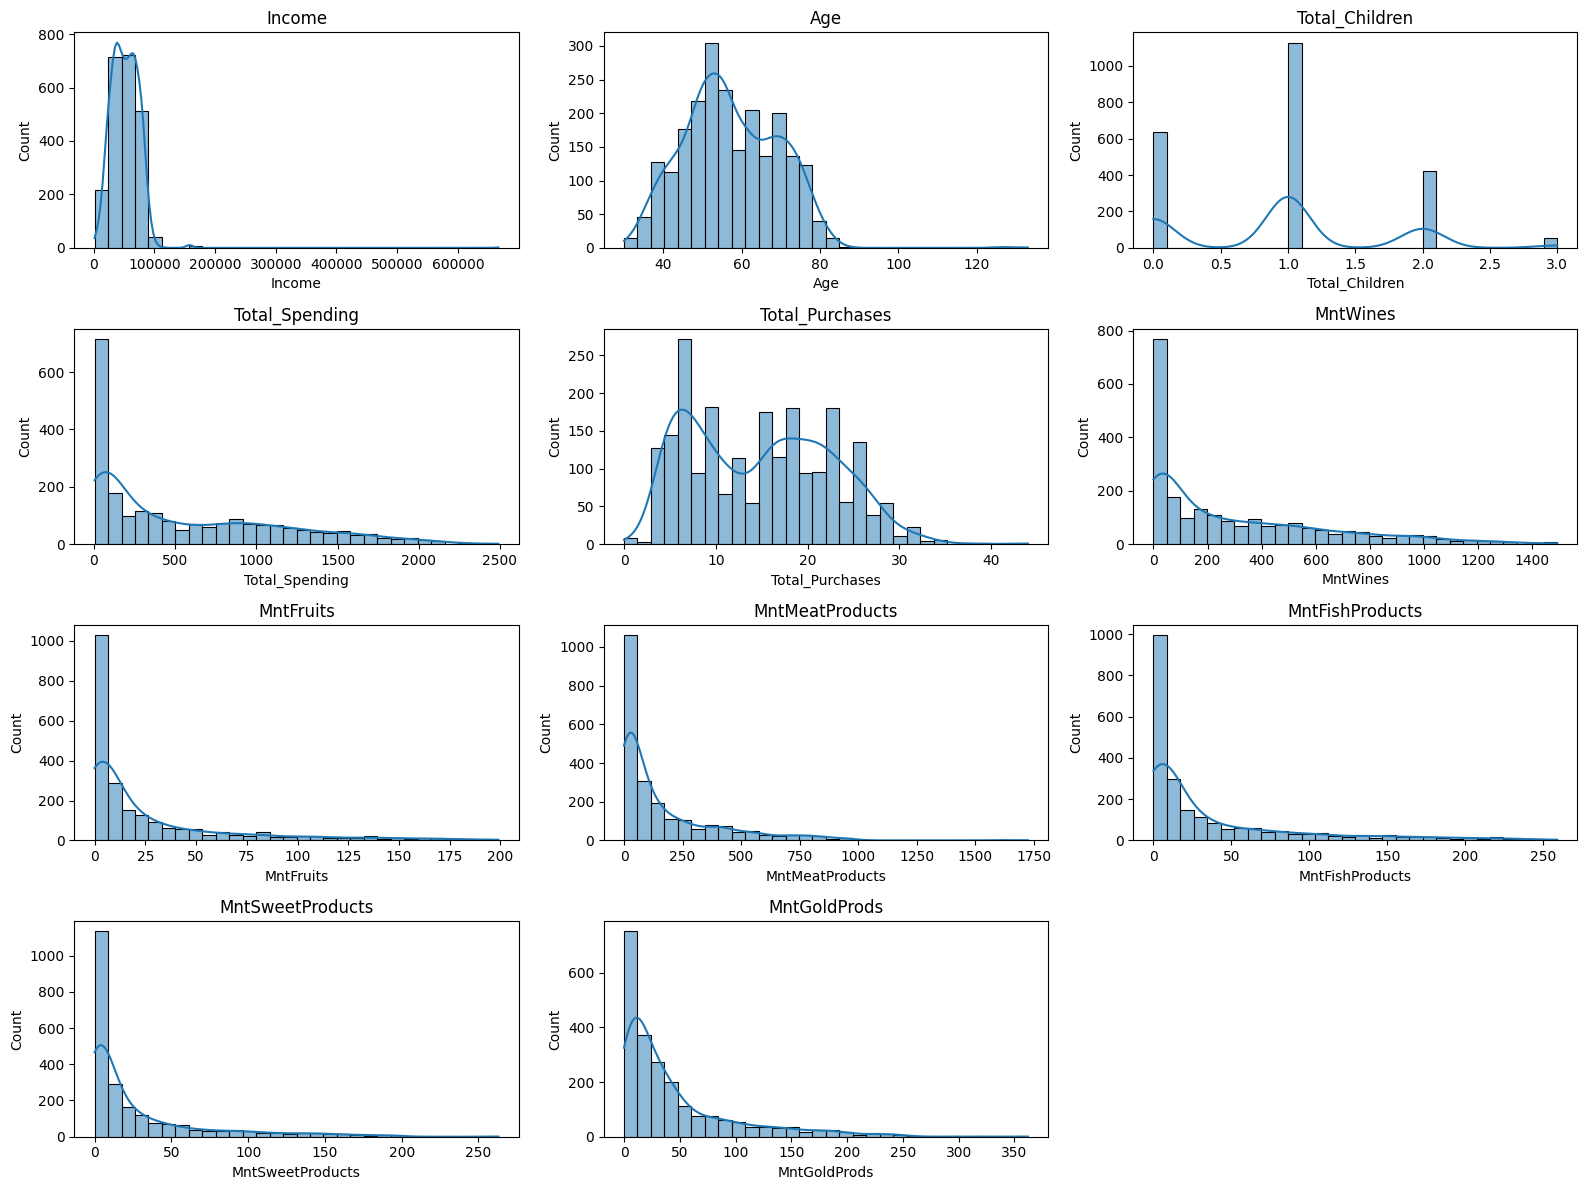

In [67]:
plt.figure(figsize=(16 , 12))

for i, col in enumerate(num_cols, 1):
 plt.subplot(4,3,i)
 sns.histplot(marketing_data[col], kde=True, bins=30)
 plt.title(col)

plt.tight_layout()
plt.show()


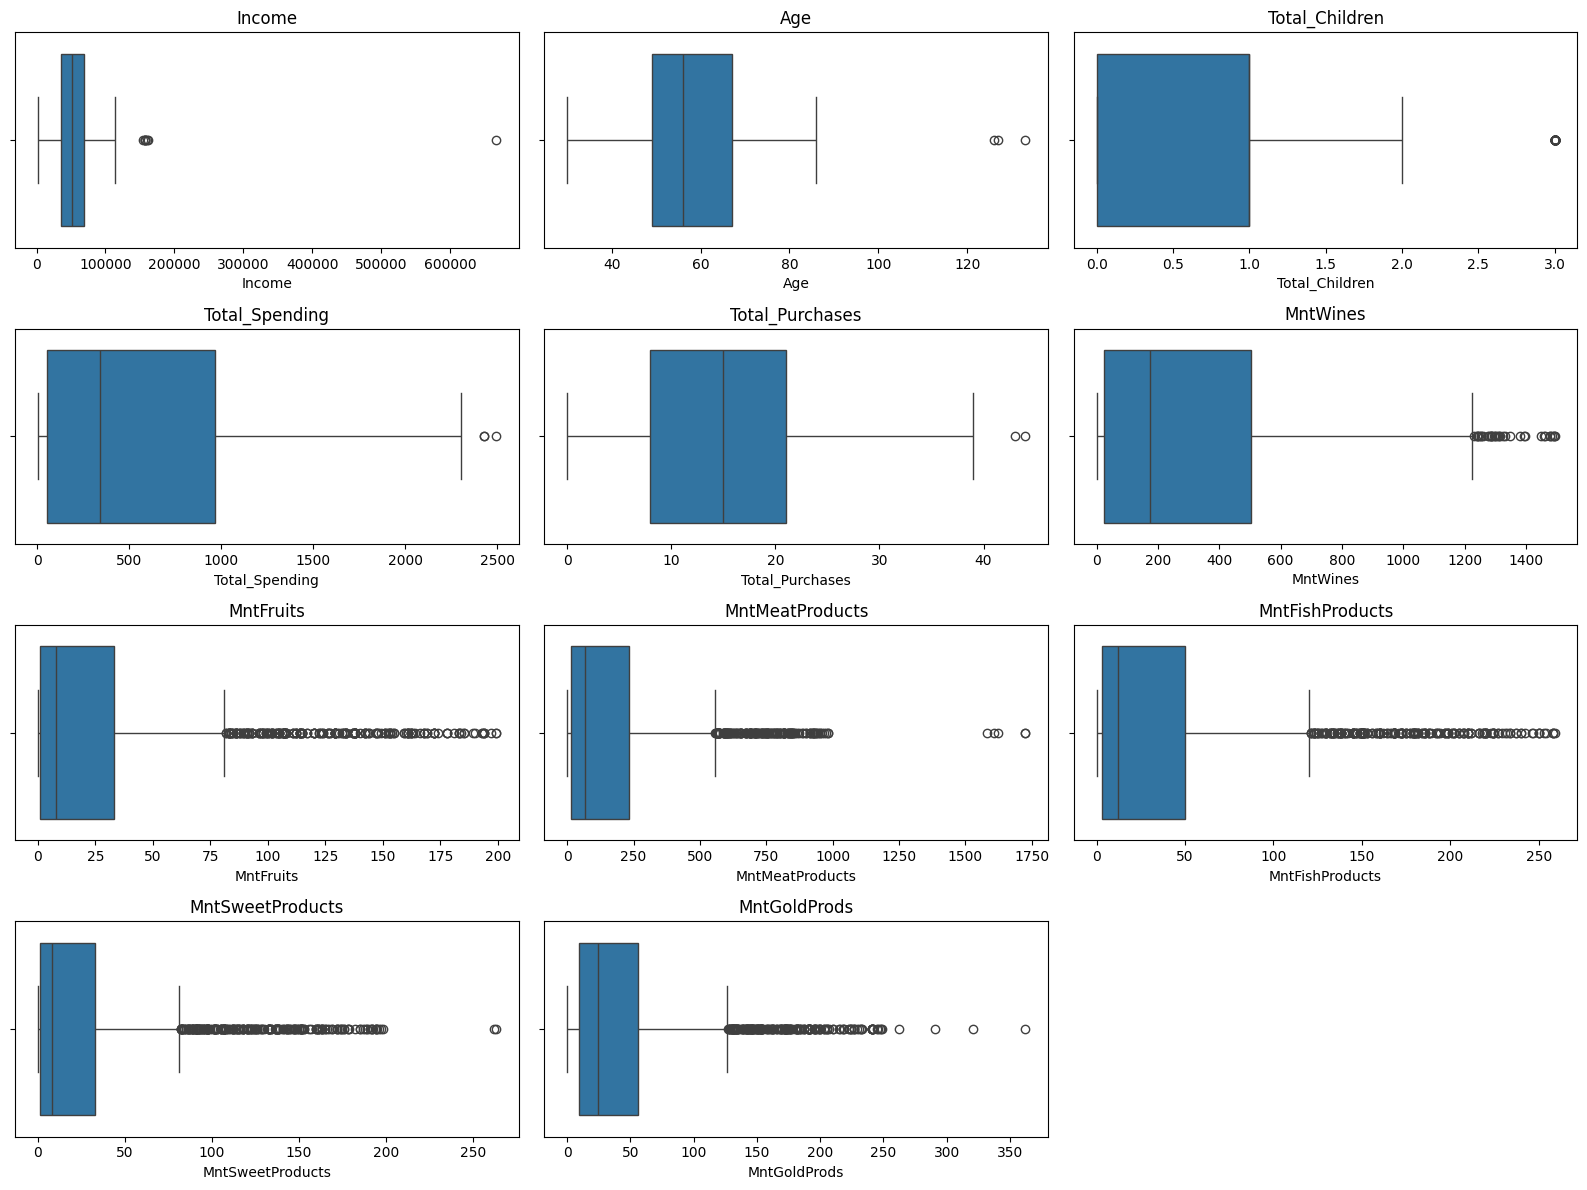

In [68]:
# Box plot Visualization

plt.figure(figsize=(16 , 12))

for i, col in enumerate(num_cols, 1):
  plt.subplot(4,3,i)
  sns.boxplot(x=marketing_data[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [69]:
# Outlier Treatment IQR method

marketing_data_capped = marketing_data.copy()

for col in num_cols:
  q1 = marketing_data_capped[col].quantile(0.25)
  q3 = marketing_data_capped[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

#cap Value

marketing_data_capped[col] = marketing_data_capped[col].clip(lower=lower_bound, upper=upper_bound)

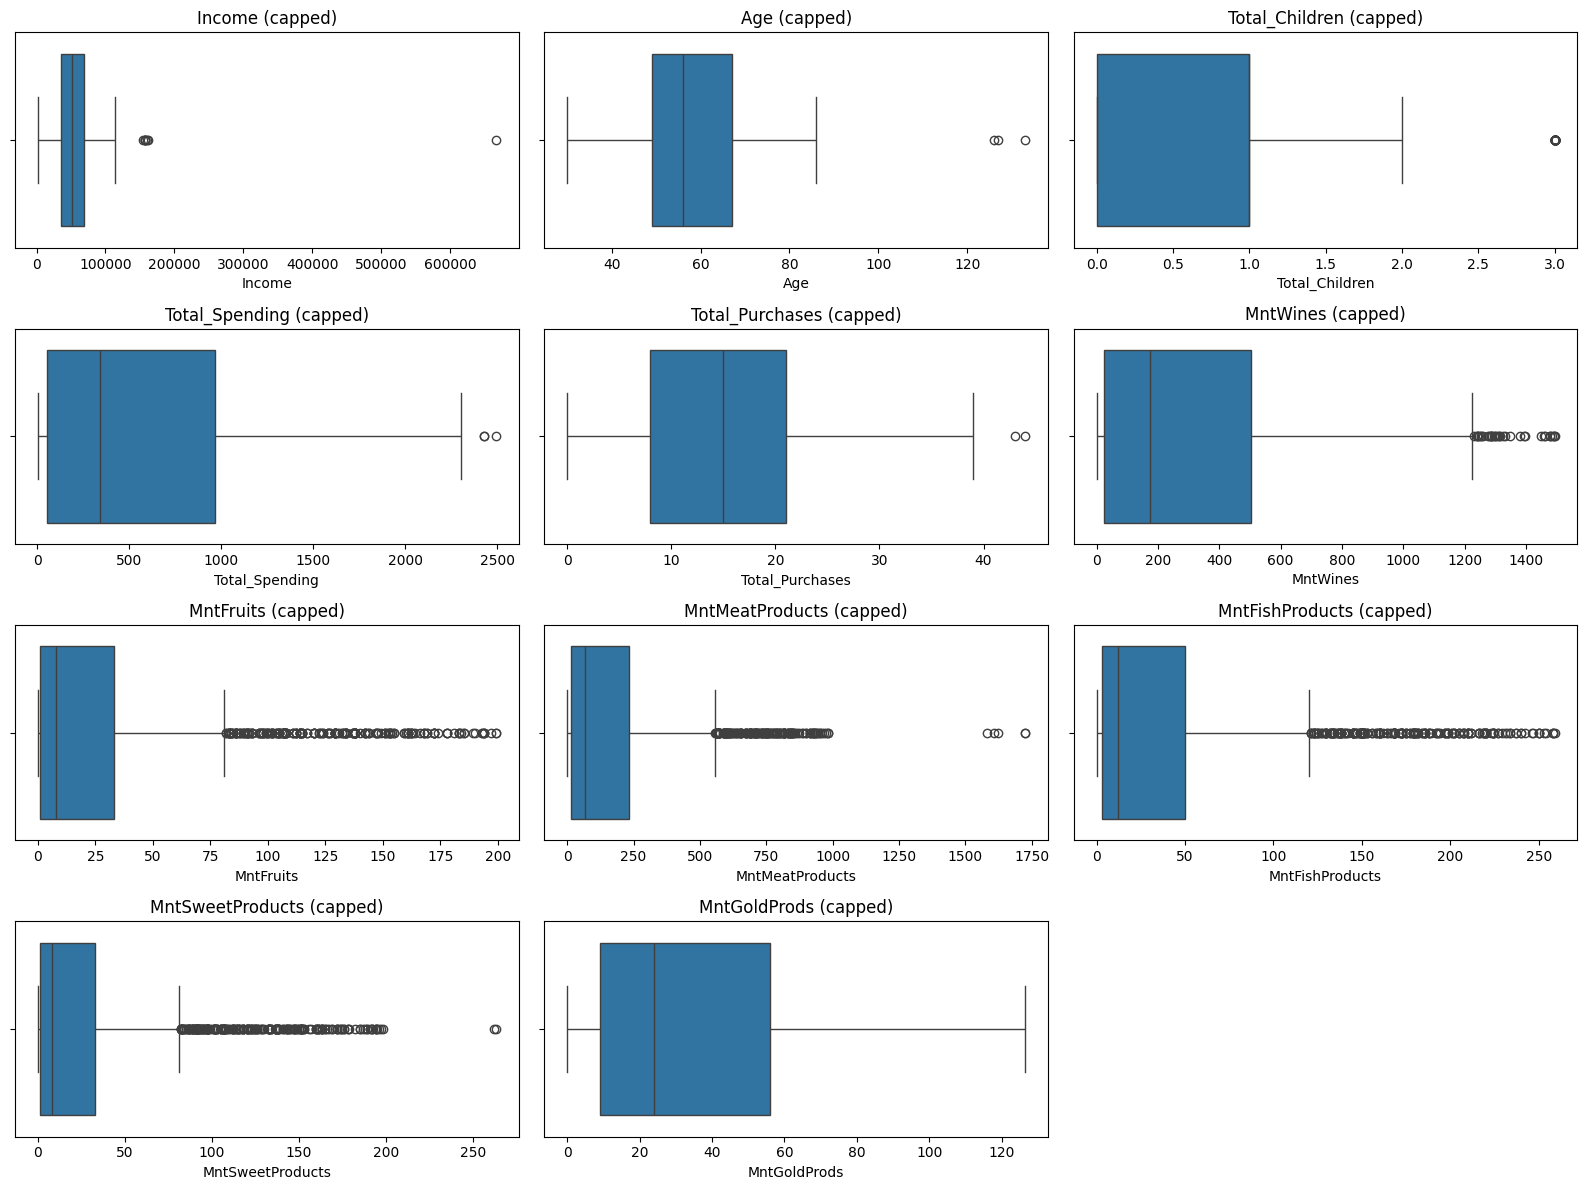

In [70]:
# Final check

plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=marketing_data_capped[col])
    plt.title(col + ' (capped)')

plt.tight_layout()
plt.show()


8.	Apply ordinal and one-hot encoding based on the various types of categorical variables.

In [71]:
#Apply ordinal and one-hot encoding based on the various types of categorical variables.
#
# Following are categorical columns
#2.   Education (Customer's education level)         2240 non-null   object  ------ Categorical (Allowed - Graduation, PhD, 2n Cycle, Master, Basic)
# 3.   Marital_Status (Customer's marital status      2240 non-null   object  ------ Categorical (Allowed - Divorced, Single, Married, Together, Widow, YOLO, Alone, Absurd)
# 27.  Country (Customer's location)                  2240 non-null   object  ------ Categorical (Allowed - SP, CA, US, AUS, GER, IND, SA, ME)

In [72]:
# Define education order (low to high)
education_order = {
    'Basic': 1,
    '2n Cycle': 2,
    'Graduation': 3,
    'Master': 4,
    'PhD': 5
}

marketing_data['Education_ordinal'] = marketing_data['Education_clean'].map(education_order)

marketing_data[['Education_clean', 'Education_ordinal']].head()

,Education_clean,Education_ordinal
0,Graduation,3
1,Graduation,3
2,Graduation,3
3,Graduation,3
4,Graduation,3


In [73]:
# One-hot encoding (Marital_Status & Country)
#   These are nominal (no natural order), so we use one-hot encoding.
#

categorical_nominal = ['Marital_Status_clean', 'Country']

marketing_data_encoded = pd.get_dummies(marketing_data, columns=categorical_nominal, drop_first=True)  # avoid dummy variable trap

marketing_data_encoded.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Education_clean',
       'Income_Imputed', 'Total_Children', 'Age', 'Total_Spending',
       'Total_Purchases', 'Education_ordinal', 'Marital_Status_clean_Married',
       'Marital_Status_clean_Other', 'Marital_Status_clean_Single',
       'Marital_Status_clean_Together', 'Marital_Status_clean_Widow',
       'Country_CA', 'Country_GER', 'Country_IND', 'Country_ME', 'Country_SA',
       'Country_SP', 'Country_US'],
      dtype='object')

In [74]:
# Quick check for final encoded data

marketing_data_encoded[[
    'Education_clean',
    'Education_ordinal',
    'Marital_Status_clean_Married',
    'Marital_Status_clean_Single',
    'Country_CA',
    'Country_US'
]].head(20)

,Education_clean,Education_ordinal,Marital_Status_clean_Married,Marital_Status_clean_Single,Country_CA,Country_US
0,Graduation,3,False,False,False,False
1,Graduation,3,False,True,True,False
2,Graduation,3,True,False,False,True
3,Graduation,3,False,False,False,False
4,Graduation,3,False,True,False,False
5,PhD,5,False,True,False,False
6,2n Cycle,2,True,False,False,False
7,Graduation,3,False,False,False,False
8,PhD,5,True,False,False,True
9,PhD,5,True,False,False,False


9.	Generate a heatmap to illustrate the correlation between different pairs of variables

In [75]:
#	Generate a heatmap to illustrate the correlation between different pairs of variables .

#Choose numeric columns for correlation
num_cols_for_corr = [
    'Income',      # final income
    'Age',
    'Total_Children',
    'Total_Spending',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Response'
]


In [76]:
# Compute correlation matrix

Corr = marketing_data[num_cols_for_corr].corr()

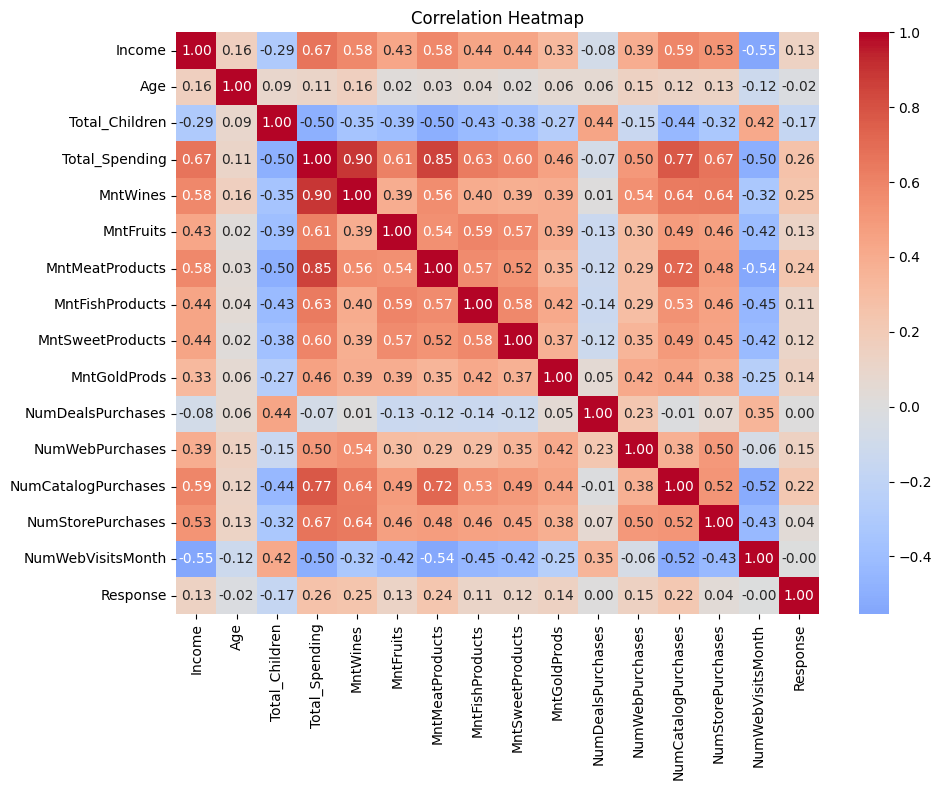

In [77]:
# Plot the heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    Corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

10.	Test the following hypotheses:

a.	Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.

b.	Customers with children likely experience time constraints, making online shopping a more convenient option.

c.	Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

d.	Does the United States significantly outperform the rest of the world in total purchase volumes?


In [78]:
# a. Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.



In [79]:
# Total  purchase

marketing_data['Total_Purchases'] = (
    marketing_data['NumStorePurchases'] +
    marketing_data['NumWebPurchases'] +
    marketing_data['NumCatalogPurchases'])

# Total store purchase

marketing_data['Total_Store'] = marketing_data['NumStorePurchases']

# Total online Purchase

marketing_data['Total_Online'] = (
    marketing_data['NumWebPurchases'] +
    marketing_data['NumCatalogPurchases']
)

In [80]:
# Older vs younger – store & online

age_median = marketing_data['Age'].median()
marketing_data['Age_group'] = np.where(marketing_data['Age'] >= age_median, 'older' , 'younger')

# Mean and median store & online purchases by age group

Age_group_stats = marketing_data.groupby('Age_group')[['Total_Store','Total_Online']].agg(['mean' , 'median'])

print("Age group stats (store & online):")
print(Age_group_stats)

Age group stats (store & online):
          Total_Store        Total_Online       
                 mean median         mean median
Age_group                                       
older        6.223764    5.0     7.475282    7.0
younger      5.330267    4.0     5.974241    5.0


Hypothesis: older customers do more store purchases (and maybe less online).

Mean purchases by age group:
​


Age_group	Total_Store	Total_Online
Older	6.22	7.48
Younger	5.33	5.97
Older customers make more store purchases on average than younger (6.22 vs 5.33).
​


They also make more online purchases than younger (7.48 vs 5.97).
​


Conclusion:

You can say older customers do buy more in-store, but they also buy more online; they are not avoiding online channels. So this hypothesis is only partially supported.

# Customers with children likely experience time constraints, making online shopping a more convenient option.

In [85]:
# Flag customers with children

marketing_data['Has_children'] = np.where(marketing_data['Total_Children']>0 , 1,0)

# Mean and median store & online purchases by children flag

children_stats = marketing_data.groupby('Has_children')[['Total_Store' , 'Total_Online']].agg(['mean' , 'median'])

print("Children stats (store & online):")
print(children_stats)





Children stats (store & online):
             Total_Store        Total_Online       
                    mean median         mean median
Has_children                                       
0               7.264890    7.0     9.152038   10.0
1               5.202871    4.0     5.789014    4.5


In [82]:

# Customers with children prefer online?--
#=====================================================================================
#| Has_children | Total_Store | Total_Online |
#| ------------ | ----------- | ------------ |
#| 0 (no kids)  | 7.26        | 9.15         |
#| 1 (kids)     | 5.20        | 5.79         |


#Customers without children actually buy more both in store and online.
​

#Customers with children purchase less overall, including online.

#Conclusion:

#This dataset does not support the hypothesis that customers with children lean more to online. They are less active overall, including online.


Are stores cannibalized by other channels

Hypothesis: more online purchases reduce store purchases (negative relation).

Correlation between store and online counts:
​


Corr(Total_Store, Total_Online) ≈ 0.62 (strong positive).

​

Interpretation:

Customers who buy more online also tend to buy more in store.

This looks more like multi-channel heavy users than cannibalization.

Conclusion:

No evidence of cannibalization here; channels move together, not against each other.

Does the United States significantly outperform the rest of the world in total purchase volumes



In [90]:
# US vs Rest of World – total purchases


# US stats
us_stats = marketing_data.loc[marketing_data['Country']== 'US', 'Total_Purchases'].agg(['mean', 'median' , 'count'])

# Rest of world stats

row_stats = marketing_data.loc[marketing_data['Country']!= 'US', 'Total_Purchases'].agg(['mean', 'median' , 'count'])

print("\nUS Total_Purchases stats:")
print(us_stats)

print("\nRest of World Total_Purchases stats:")
print(row_stats)

# Country level comparison
country_stats = marketing_data.groupby('Country')['Total_Purchases'].agg(['mean','median','count']).sort_values('mean', ascending=False)
print("\nCountry-level Total_Purchases stats (sorted by mean):")
print(country_stats)


US Total_Purchases stats:
mean       13.513761
median     13.000000
count     109.000000
Name: Total_Purchases, dtype: float64

Rest of World Total_Purchases stats:
mean        12.487095
median      12.000000
count     2131.000000
Name: Total_Purchases, dtype: float64

Country-level Total_Purchases stats (sorted by mean):
              mean  median  count
Country                          
ME       17.333333    16.0      3
US       13.513761    13.0    109
CA       12.899254    14.0    268
SA       12.765579    12.0    337
GER      12.750000    12.5    120
SP       12.404566    12.0   1095
AUS      12.200000    11.0    160
IND      11.716216    11.0    148


Average Total_Purchases:
​

US customers: ≈ 13.51 purchases.

Rest of world: ≈ 12.49 purchases.

By country (mean Total_Purchases, top): ME ≈ 17.33, US ≈ 13.51, CA ≈ 12.90, SA ≈ 12.77, GER ≈ 12.75, SP ≈ 12.40…
​

Conclusion:

US customers buy slightly more than the rest of the world on average (about +1 purchase), but they are not dramatically higher.

Also, ME (Middle East) has the highest mean, though with very few records (3 customers)

11. 	Use appropriate visualization to help analyze the following

a.	Identify the top-performing products and those with the lowest revenue.

b.	Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.

c.	Determine the country with the highest number of customers who accepted the last campaign.

d.	Investigate if there is a discernible pattern in the number of children at home and the total expenditure.

e.	Analyze the educational background of customers who lodged complaints in the last two years.


In [91]:
# Visualization method for : Identify the top-performing products and those with the lowest revenue.

product_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

product_totals = marketing_data[product_cols].sum().sort_values(ascending=False)
print(product_totals)


MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64


/tmp/ipykernel_8931/3525652541.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_totals.index, y=product_totals.values, palette='viridis')


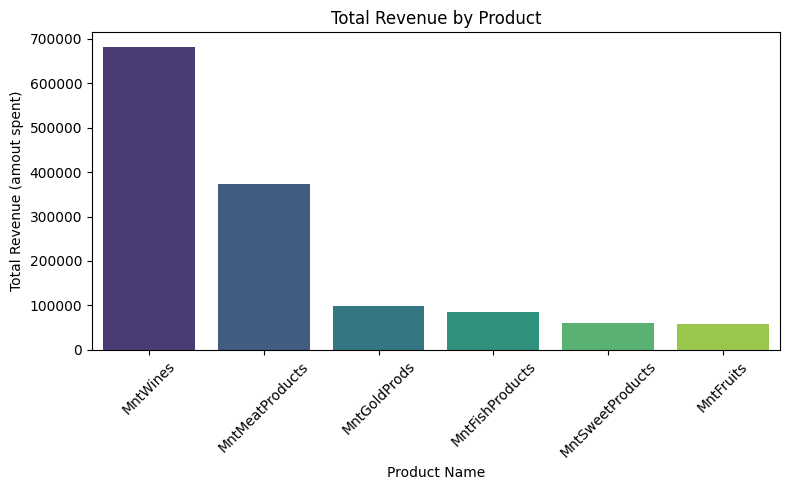

In [95]:
# Visualization plot for Product cols

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8 ,5))
sns.barplot(x=product_totals.index, y=product_totals.values, palette='viridis')
plt.ylabel('Total Revenue (amout spent)')
plt.xlabel('Product Name')
plt.title('Total Revenue by Product')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#So:

#Top-performing product by revenue: MntWines, then MntMeatProducts.
​

#Lowest revenue product: MntFruits (slightly below sweets)

b.	Examine if there is a correlation between customers' age and the acceptance rate of the last campaign

Age_band
18-30    0.500000
31-40    0.165775
41-50    0.152174
51-60    0.154745
61+      0.135654
Name: Response, dtype: float64


/tmp/ipykernel_8931/1298600084.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_band_rates = marketing_data.groupby('Age_band')['Response'].mean()


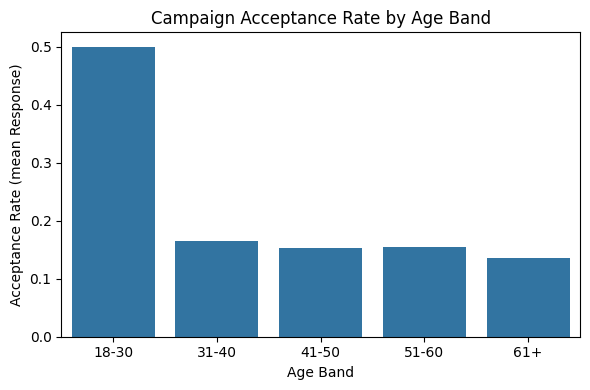

In [103]:
# # Acceptance rate by age band (bar chart)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
marketing_data['Age_band'] = pd.cut(marketing_data['Age'],
                                    bins = [17 , 30 , 40 , 50 , 60 , 80],
                                    labels=['18-30', '31-40', '41-50', '51-60', '61+'])

# Mean Response (acceptance rate) per age band
age_band_rates = marketing_data.groupby('Age_band')['Response'].mean()

print(age_band_rates)

plt.figure(figsize=(6, 4))
sns.barplot(x=age_band_rates.index, y=age_band_rates.values)
plt.ylabel('Acceptance Rate (mean Response)')
plt.xlabel('Age Band')
plt.title('Campaign Acceptance Rate by Age Band')
plt.tight_layout()
plt.show()

In [ ]:
# Campaign accepted by Age is 18-30 max

c.	Determine the country with the highest number of customers who accepted the last campaign

Country with highest number of accepted customers
Count of customers with Response = 1 by country:
​

SP: 176

SA: 52

CA: 38

AUS: 23

GER: 17

IND: 13

US: 13

ME: 2

So the country with the highest number of customers who accepted the last campaign is SP (Spain) with 176 acceptances

/tmp/ipykernel_8931/3757931458.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accepted_by_country.index, y=accepted_by_country.values, palette='Blues_d')


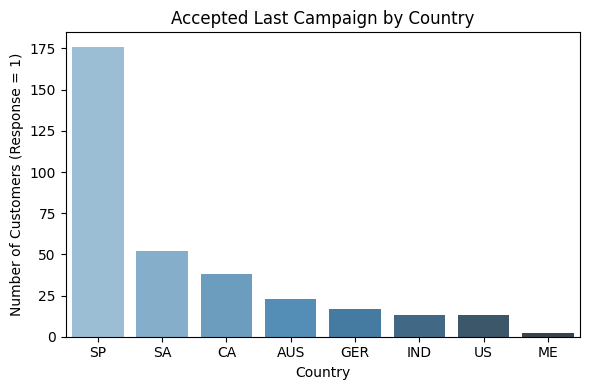

In [111]:
# Visualization code (bar chart)

import seaborn as sns
import matplotlib.pyplot as plt

# Filter accepted customers and count by country

accepted_by_country = marketing_data[marketing_data['Response'] == 1]['Country'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=accepted_by_country.index, y=accepted_by_country.values, palette='Blues_d')
plt.xlabel('Country')
plt.ylabel('Number of Customers (Response = 1)')
plt.title('Accepted Last Campaign by Country')
plt.tight_layout()
plt.show()

d.	Investigate if there is a discernible pattern in the number of children at home and the total expenditure

In [116]:
# Total spending across all products

spend_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

marketing_data['Total_Spending'] = marketing_data[spend_cols].sum(axis=1)

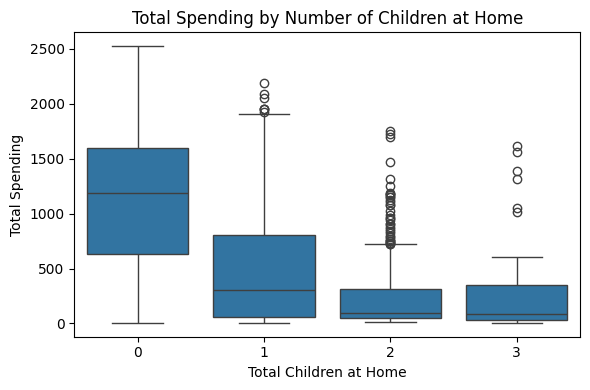

In [117]:
# Boxplot: Total spending by number of children

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(
    x='Total_Children',
    y='Total_Spending',
    data=marketing_data
)
plt.xlabel('Total Children at Home')
plt.ylabel('Total Spending')
plt.title('Total Spending by Number of Children at Home')
plt.tight_layout()
plt.show()

e.	Analyze the educational background of customers who lodged complaints in the last two years

In [120]:
# Customers who lodged a complaint

complainers = marketing_data[marketing_data['Complain'] == 1]

# Education distribution

edu_counts = complainers['Education'].value_counts()
print(edu_counts)

Education
Graduation    14
2n Cycle       4
Master         2
PhD            1
Name: count, dtype: int64


/tmp/ipykernel_8931/1009820494.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


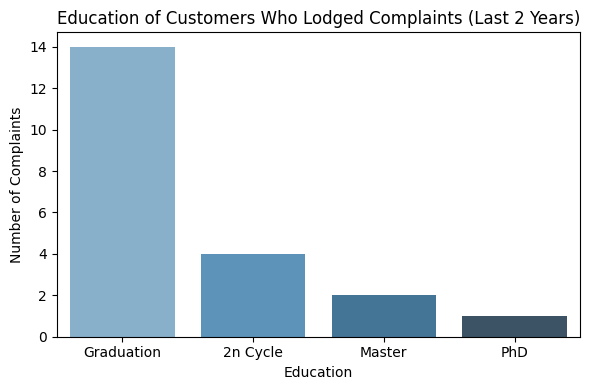

In [122]:
# Visualization: bar chart of education among complainers

import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 4))
sns.barplot(
    x=edu_counts.index,
    y=edu_counts.values,
    palette='Blues_d'
)
plt.xlabel('Education')
plt.ylabel('Number of Complaints')
plt.title('Education of Customers Who Lodged Complaints (Last 2 Years)')
plt.tight_layout()
plt.show()

In [ ]:
# This bar chart makes it clear that Graduation dominates, with fewer complaints from 2n Cycle, Master, and PhD customers.